# Random Forest - Bias & Variance Trade-off [ Classification ]
- Bias (Underfitting): High bias occurs when a model is too simple to capture the underlying patterns of the data. For the circular dataset provided, a linear classifier would have high bias because it cannot represent a circular boundary.

- Variance (Overfitting): High variance occurs when a model "memorizes" the training data rather than learning the general pattern. A single, unpruned Decision Tree often exhibits high variance by creating extremely jagged boundaries to capture every outlier. 

* The goal is to find a balance between low bias and low variance.
* The Random Forest algorithm is specifically designed to navigate this trade-off through Bagging (Bootstrap Aggregating).
   - Reducing Variance: By training multiple decision trees on different subsets of the data and averaging their results, the "noise" captured by individual trees cancels out. This leads to a smoother decision boundary that generalizes better to unseen data.
   - Maintaining Low Bias: Because the individual trees are allowed to grow deep (capturing the complex circular shape), the ensemble retains the ability to model non-linear relationships, keeping bias low.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_circles
from mlxtend.plotting import plot_decision_regions

In [14]:
np.random.seed(15)
X,y = make_circles(n_samples = 500 , noise=0.35 , factor = 0.1 , random_state= 42)
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2)

### Scatter Plot For Dataset 

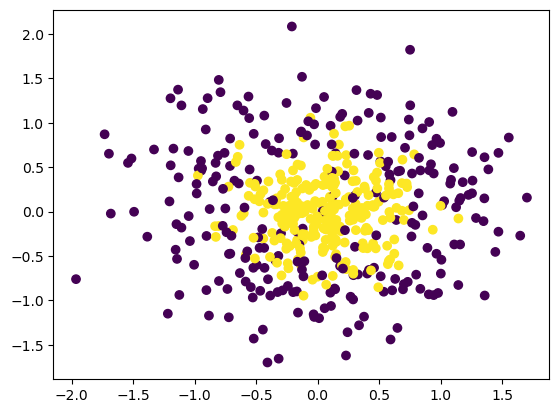

In [16]:
plt.scatter(X[:,0],X[:,1],c= y)
plt.show()

### Bias & Variance Checking Through Decision tree 

In [41]:
decision_tree = DecisionTreeClassifier() 
decision_tree.fit(X_train,y_train)

DecisionTreeClassifier()

### Decision Boundary

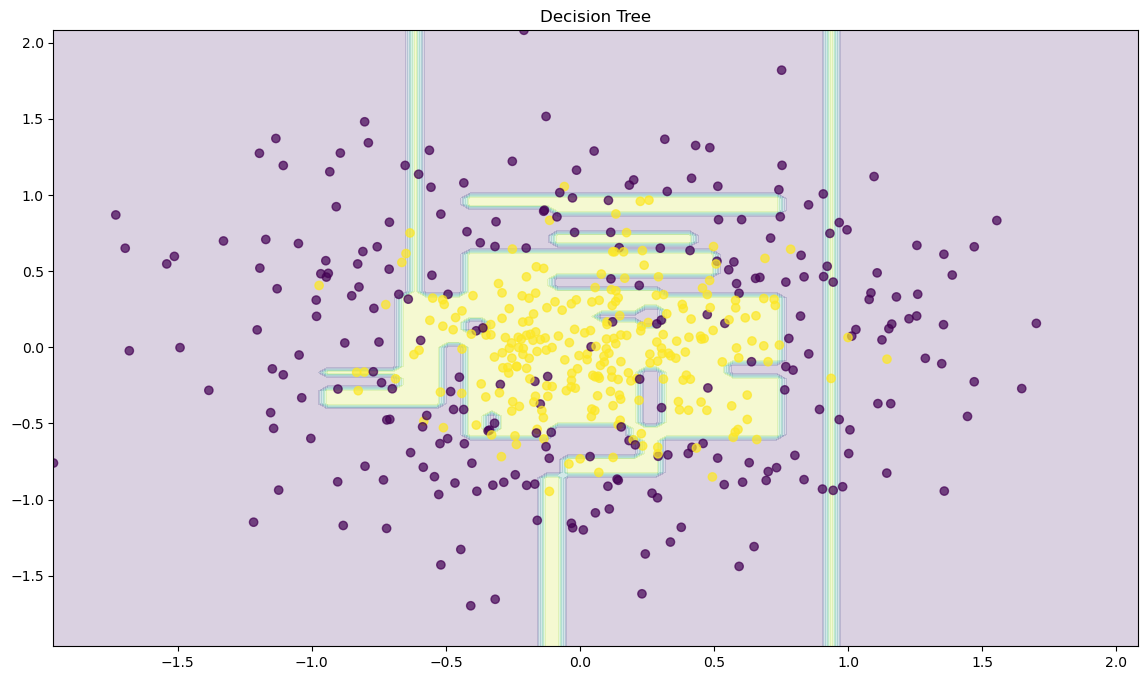

In [20]:
plt.figure(figsize=(14,8))
x_range = np.linspace(X.min(),X.max(), 100)
xx1,xx2 = np.meshgrid(x_range,x_range)
y_hat = decision_tree.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1,xx2,y_hat,alpha = 0.2)
plt.scatter(X[:,0],X[:,1], c=y, cmap = "viridis", alpha=0.7)
plt.title("Decision Tree")
plt.show()

### Checking Bias & Variance Through Random Forest

In [22]:
random_forest = RandomForestClassifier(n_estimators=500,random_state=42)
random_forest.fit(X_train,y_train)

RandomForestClassifier(n_estimators=500, random_state=42)

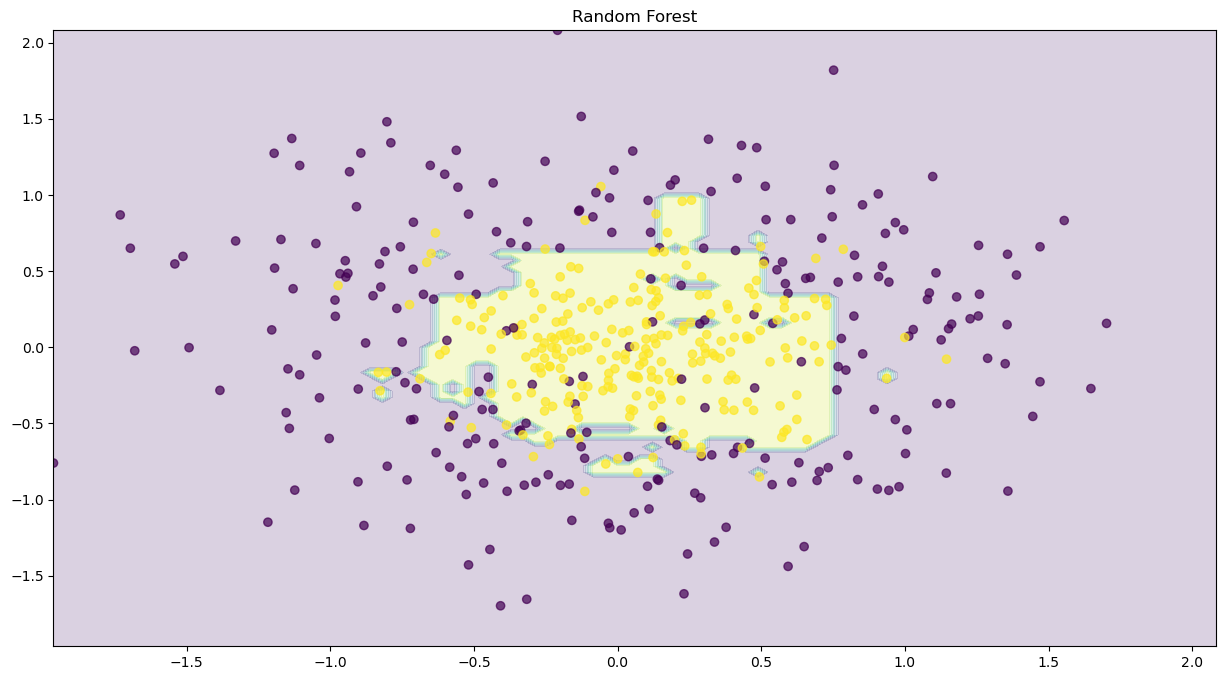

In [23]:
plt.figure(figsize=(15,8))
x_range = np.linspace(X.min(),X.max(), 100)
xx1,xx2 = np.meshgrid(x_range,x_range)
y_hat = random_forest.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1,xx2,y_hat,alpha = 0.2)
plt.scatter(X[:,0],X[:,1], c=y, cmap = "viridis", alpha=0.7)
plt.title("Random Forest")
plt.show()